In [1]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt

# Data Cleaning and Processing

In [2]:
F1 =  pd.read_csv('customer_churn_dataset-testing-master.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'customer_churn_dataset-testing-master.csv'

In [3]:
F1.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [4]:
F1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [5]:
F2 =  F1.drop(['CustomerID'],axis = 'columns')

In [6]:
F2.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [8]:
print(F2.columns)

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='object')


In [9]:
F2['Gender'] = le.fit_transform(F2['Gender'])
F2['Subscription Type'] = le.fit_transform(F2['Subscription Type'])
F2['Contract Length'] = le.fit_transform(F2['Contract Length'])

In [10]:
F2.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,0,25,14,4,27,0,1,598,9,1
1,41,0,28,28,7,13,2,1,584,20,0
2,47,1,27,10,2,29,1,0,757,21,0
3,35,1,9,12,5,17,1,2,232,18,0
4,53,0,58,24,9,2,2,0,533,18,0


In [11]:
F2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                64374 non-null  int64
 1   Gender             64374 non-null  int32
 2   Tenure             64374 non-null  int64
 3   Usage Frequency    64374 non-null  int64
 4   Support Calls      64374 non-null  int64
 5   Payment Delay      64374 non-null  int64
 6   Subscription Type  64374 non-null  int32
 7   Contract Length    64374 non-null  int32
 8   Total Spend        64374 non-null  int64
 9   Last Interaction   64374 non-null  int64
 10  Churn              64374 non-null  int64
dtypes: int32(3), int64(8)
memory usage: 4.7 MB


#  EDA :- Exploratory Data Analysis

# Churn Distribution

<Axes: xlabel='Churn', ylabel='count'>

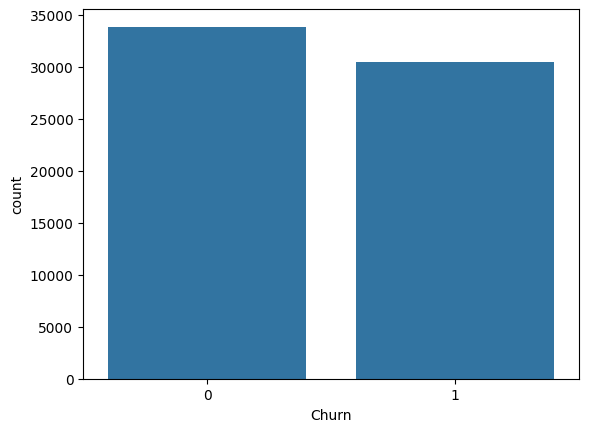

In [12]:
sn.countplot(x='Churn',data = F2)

# Univariate Analysis

In [13]:
def UA(feature):
    plt.figure(figsize=(6,4))
    sn.histplot(F2[feature], bins=30, kde=True)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()


In [14]:
features = ['Age','Tenure','Subscription Type','Total Spend']

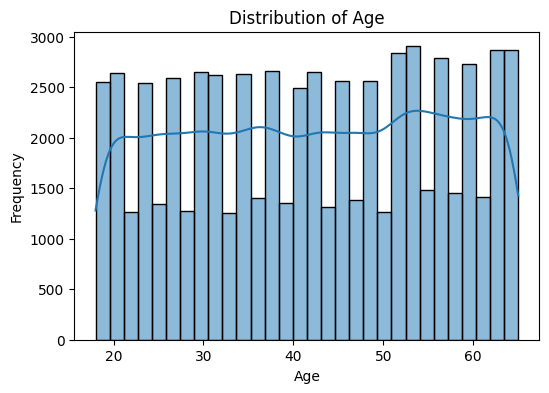

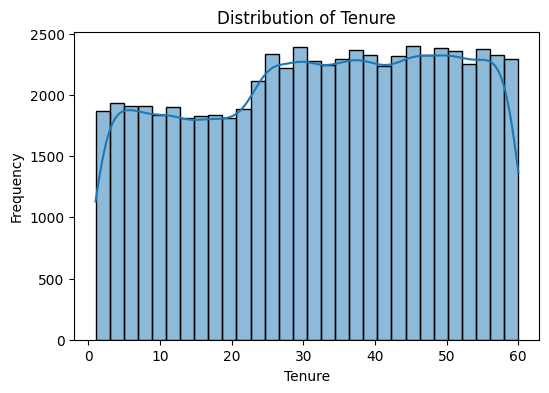

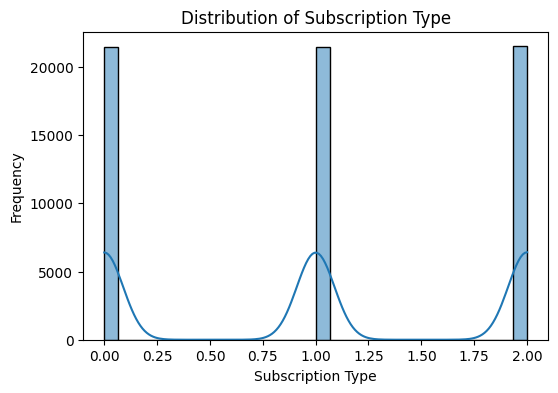

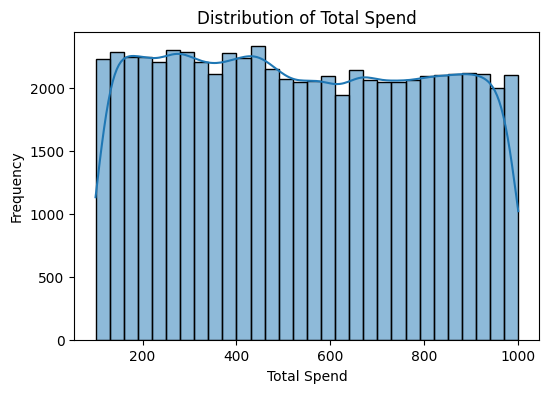

In [15]:
for feature in features:
    UA(feature)

# Bivariate_Analysis

In [16]:
def BA(F):
    plt.figure(figsize=(6,4))
    sn.boxplot(x = 'Churn', y = F , data = F2)
    plt.title(f"Distribution of churn vs {F}")
    plt.xlabel('churn')
    plt.ylabel(F)
    plt.show()
    return
    
    

In [17]:
fea = ['Age','Tenure','Usage Frequency','Support Calls','Payment Delay','Total Spend','Last Interaction']

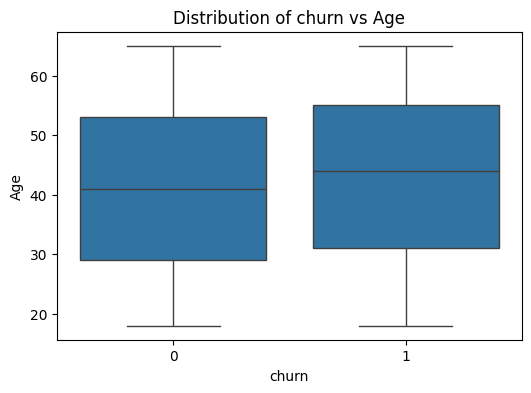

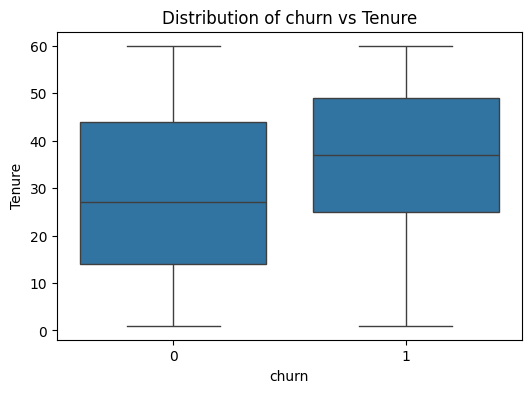

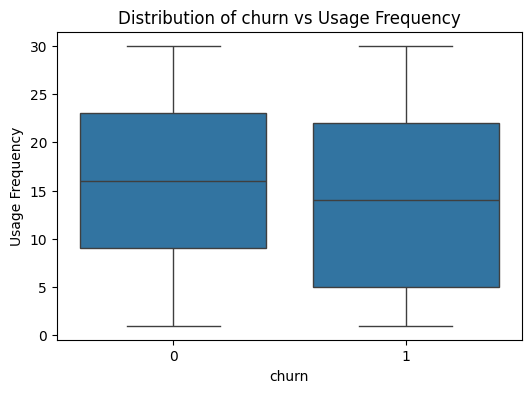

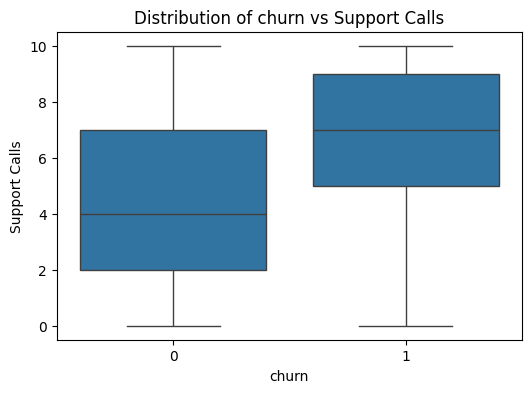

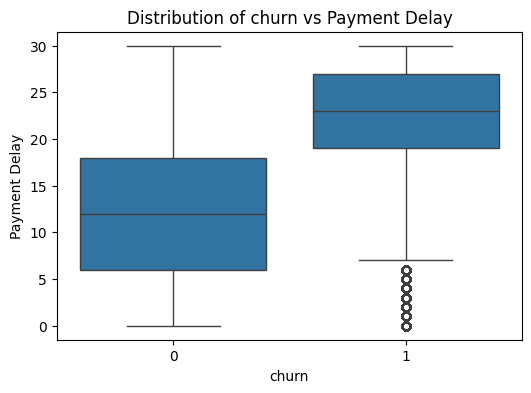

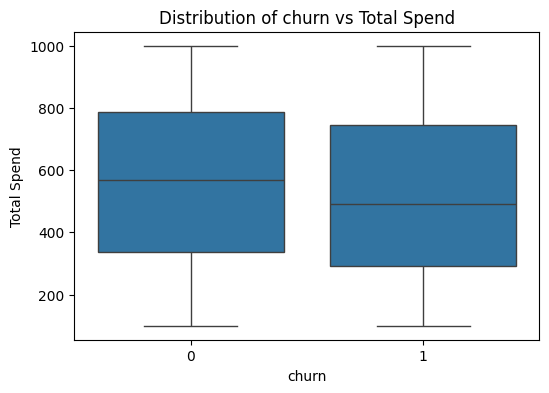

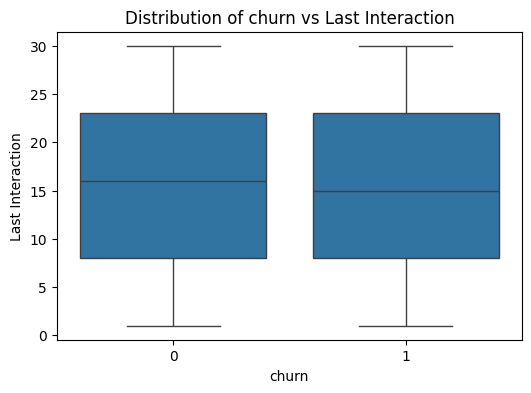

In [18]:
for f in fea:
    BA(f)

# Categorical_Feature_Analysis

In [19]:
def CFA(feature):
    plt.figure(figsize=(6,4))
    sn.countplot(x=feature , hue = 'Churn', data = F2)
    plt.title(f"Categorical_Feature_Analysis {feature}")
    plt.xlabel(feature)
    plt.ylabel('Churn')
    plt.show()

In [20]:
feat = ['Gender','Subscription Type','Contract Length']

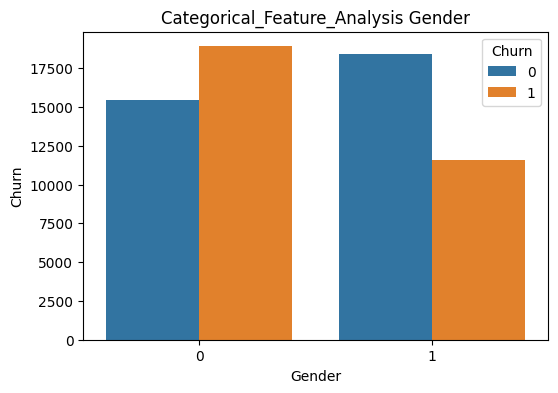

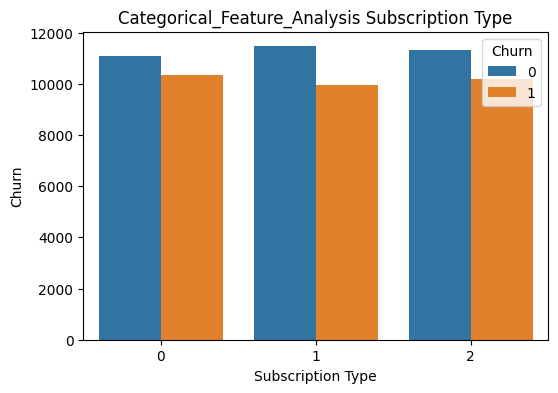

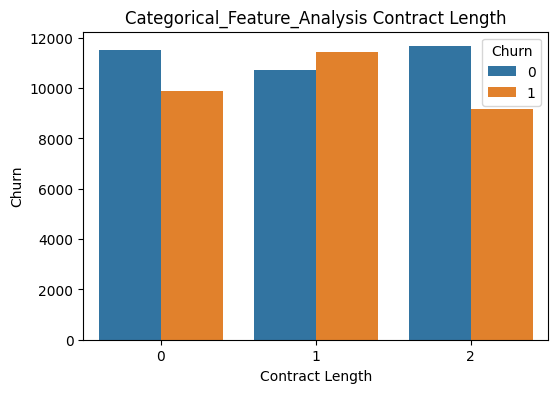

In [21]:
for fa in feat:
    CFA(fa)

# Correlation_Heatmap

<Axes: >

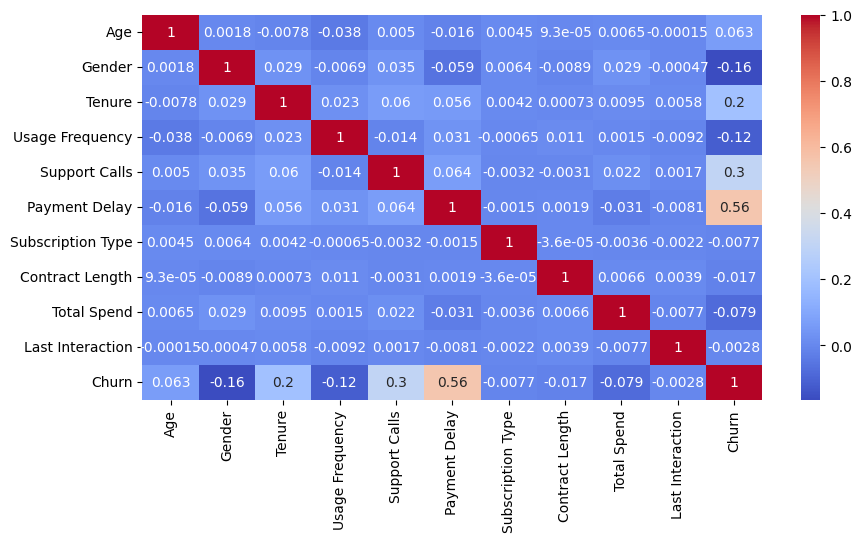

In [22]:
plt.figure(figsize=(10,5))
sn.heatmap(F2.corr(),cmap = 'coolwarm',annot = True )

# Datasplit

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X = F2.drop(['Churn'],axis = 'columns')
y = F2.Churn

In [25]:
X.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,22,0,25,14,4,27,0,1,598,9
1,41,0,28,28,7,13,2,1,584,20
2,47,1,27,10,2,29,1,0,757,21
3,35,1,9,12,5,17,1,2,232,18
4,53,0,58,24,9,2,2,0,533,18


In [26]:
y

0        1
1        0
2        0
3        0
4        0
        ..
64369    1
64370    1
64371    1
64372    1
64373    1
Name: Churn, Length: 64374, dtype: int64

In [27]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [28]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((51499, 10), (12875, 10), (51499,), (12875,))

# Hyperparameter Tunning

In [29]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [30]:
from sklearn.model_selection import cross_val_score
def objective(trial):

    classifier_name = trial.suggest_categorical(
        'classifier',
        ['LogisticRegression', 'XGBClassifier', 'CatBoostClassifier']
    )
    
#----------LogisticRegression-----------#
    if classifier_name == 'LogisticRegression':
        solver = trial.suggest_categorical(
            'solver',
            ['liblinear', 'saga']
        )

        penalty = trial.suggest_categorical(
            'penalty',
            ['l1', 'l2', 'elasticnet']
        )

    # invalid combinations
        if solver == 'liblinear' and penalty == 'elasticnet':
            raise optuna.exceptions.TrialPruned()

        C = trial.suggest_float(
            'C',
            0.01,
            10,
            log=True
        )

        max_iter = trial.suggest_int(
            'max_iter',
            100,
            1000
        )

        l1_ratio = None

        if penalty == 'elasticnet':
           l1_ratio = trial.suggest_float(
               'l1_ratio',
               0.0,
               1.0
           )

        model = LogisticRegression(
            C=C,
            penalty=penalty,
            solver=solver,
            max_iter=max_iter,
            l1_ratio=l1_ratio,
            class_weight='balanced',
             random_state=42,
           n_jobs=-1
        )
      
    # ---------------- XGBoost ---------------- #

    elif classifier_name == 'XGBClassifier':

        model = XGBClassifier(

            n_estimators=trial.suggest_int(
                'n_estimators', 50, 500
            ),

            learning_rate=trial.suggest_float(
                'learning_rate', 0.01, 0.3
            ),

            max_depth=trial.suggest_int(
                'max_depth', 3, 10
            ),

            subsample=trial.suggest_float(
                'subsample', 0.6, 1.0
            ),

            colsample_bytree=trial.suggest_float(
                'colsample_bytree', 0.6, 1.0
            ),

            gamma=trial.suggest_float(
                'gamma', 0, 5
            ),

            reg_alpha=trial.suggest_float(
                'reg_alpha', 0, 5
            ),

            reg_lambda=trial.suggest_float(
                'reg_lambda', 0, 10
            ),

            eval_metric='logloss',
            random_state=42,
            n_jobs=-1,
            tree_method='hist'
        )

    # ---------------- CatBoost ---------------- #

    else:

        model = CatBoostClassifier(

            iterations=trial.suggest_int(
                'iterations', 50, 500
            ),

            learning_rate=trial.suggest_float(
                'learning_rate', 0.01, 0.3
            ),

            depth=trial.suggest_int(
                'depth', 3, 10
            ),

            l2_leaf_reg=trial.suggest_int(
                'l2_leaf_reg', 1, 20
            ),

            subsample=trial.suggest_float(
                'subsample', 0.6, 1.0
            ),

            loss_function='Logloss',
            eval_metric='Accuracy',
            random_state=42,
            verbose=0
        )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=2,                
        scoring='accuracy',
        n_jobs=-1
    ).mean()

    return score

In [32]:
import optuna
study = optuna.create_study(direction = 'maximize')
study.optimize(objective,n_trials = 20)

[I 2026-06-10 19:12:14,206] A new study created in memory with name: no-name-ff452f67-8d4d-4fc3-b788-be2f0ae166be
[I 2026-06-10 19:12:18,680] Trial 0 finished with value: 0.8235500098599361 and parameters: {'classifier': 'LogisticRegression', 'solver': 'liblinear', 'penalty': 'l1', 'C': 9.07632652951486, 'max_iter': 542}. Best is trial 0 with value: 0.8235500098599361.
[I 2026-06-10 19:12:30,742] Trial 1 finished with value: 0.8152003271311885 and parameters: {'classifier': 'LogisticRegression', 'solver': 'liblinear', 'penalty': 'l2', 'C': 0.012858828917796307, 'max_iter': 843}. Best is trial 0 with value: 0.8235500098599361.
[I 2026-06-10 19:12:40,805] Trial 2 finished with value: 0.9995728072388144 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 248, 'learning_rate': 0.1469855219734549, 'max_depth': 8, 'subsample': 0.8413874082141601, 'colsample_bytree': 0.7804246644476494, 'gamma': 1.2395707448835946, 'reg_alpha': 0.37444904947131374, 'reg_lambda': 4.01364574739598}.

In [33]:
print(f'best trial accuracy : {study.best_trial.value}')

best trial accuracy : 0.9999417453104975


In [34]:
study.best_trial.params

{'classifier': 'CatBoostClassifier',
 'iterations': 252,
 'learning_rate': 0.2251423377588111,
 'depth': 5,
 'l2_leaf_reg': 6,
 'subsample': 0.8928374705634612}

# 3. CatBoostClssifier

In [35]:
CBC = study.best_trial.params

In [41]:
model_1 = CatBoostClassifier(
    iterations= CBC['iterations'],
    learning_rate=CBC['learning_rate'],
    depth=CBC['depth'],
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=0,
    l2_leaf_reg = CBC['l2_leaf_reg'],
    subsample = CBC['subsample']
)

In [42]:
model_1.fit(X_train,y_train)

CatBoostClassifier(depth=5, eval_metric='Accuracy', iterations=252, l2_leaf_reg=6, learning_rate=0.2251423377588111, loss_function='Logloss', random_seed=42, subsample=0.8928374705634612, verbose=0)

In [43]:
model_1.score(X_train,y_train)

1.0

In [44]:
model_1.score(X_test,y_test)

0.9999223300970874

# Evaluation Methods

In [45]:
from sklearn.metrics import confusion_matrix,classification_report,roc_curve,precision_recall_curve
from matplotlib import pyplot as plt

# Confusuion_matric & Classification_report

In [46]:
import seaborn as sn


def confusion_matrix_graph(model):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test,y_pred)
    sn.heatmap(cm,annot = True)
    plt.xlabel('predicted')
    plt.ylabel('actual')
    plt.show()
    return

def report(model):
    y_pred = model.predict(X_test)
    print(classification_report(y_test,y_pred))
    return

    

    

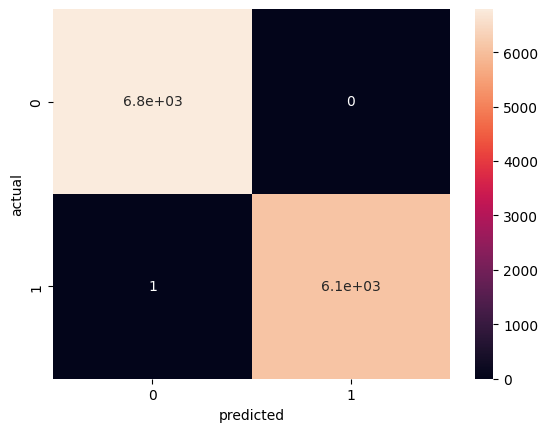

In [47]:
confusion_matrix_graph(model_1)

In [48]:
report(model_1)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6793
           1       1.00      1.00      1.00      6082

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



# Model saving


In [53]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

categorical_features = X_train.select_dtypes(
    include=['object', 'category']
).columns
numerical_features = X_train.select_dtypes(
    exclude=['object', 'category']
).columns
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numerical_features)
])


In [54]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps =[
    ('preprocessing',preprocessor),
    ('model',CatBoostClassifier(
        iterations= CBC['iterations'],
       learning_rate=CBC['learning_rate'],
       depth=CBC['depth'],
       loss_function='Logloss',
       eval_metric='Accuracy',
       random_seed=42,
       verbose=0,
       l2_leaf_reg = CBC['l2_leaf_reg'],
       subsample = CBC['subsample']
        
    ))
])

In [55]:
import pickle
Cat_Boost_Classifier = 'Cat_Boost_Classifier.pkl'
with open(Cat_Boost_Classifier,'wb') as F:
    pickle.dump(pipeline,F)